<a href="https://colab.research.google.com/github/arunjthilak80/Data-Science-Projects/blob/main/IPL_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IPL Dataset

Step 1: Import pandas, matplotlib and seaborn libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load the datasets IPL Matches 2008-2020.csv and IPL Ball-by-Ball 2008-2020.csv

In [4]:
matches_df = pd.read_csv("/content/drive/MyDrive/IPL Dataset/IPL Matches 2008-2020.csv")
deliveries_df = pd.read_csv("/content/drive/MyDrive/IPL Dataset/IPL Ball-by-Ball 2008-2020.csv")

Step 3: Inspect dimensions and columns of the 2 csv files (Matches and Deliveries) attached

In [5]:
print("Matches Shape:", matches_df.shape)
print("Deliveries Shape:", deliveries_df.shape)

Matches Shape: (816, 17)
Deliveries Shape: (193468, 18)


Step 4: View data types and missing values

In [6]:
print("\n--- Matches Summary ---")
print(matches_df.info())




--- Matches Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               816 non-null    int64  
 1   city             803 non-null    object 
 2   date             816 non-null    object 
 3   player_of_match  812 non-null    object 
 4   venue            816 non-null    object 
 5   neutral_venue    816 non-null    int64  
 6   team1            816 non-null    object 
 7   team2            816 non-null    object 
 8   toss_winner      816 non-null    object 
 9   toss_decision    816 non-null    object 
 10  winner           812 non-null    object 
 11  result           812 non-null    object 
 12  result_margin    799 non-null    float64
 13  eliminator       812 non-null    object 
 14  method           19 non-null     object 
 15  umpire1          816 non-null    object 
 16  umpire2          816 non-null    obje

In [7]:
print("Matches Info:", matches_df.info)
print("Deliveries Shape:", deliveries_df.info)

Matches Info: <bound method DataFrame.info of           id        city        date player_of_match  \
0     335982   Bangalore  2008-04-18     BB McCullum   
1     335983  Chandigarh  2008-04-19      MEK Hussey   
2     335984       Delhi  2008-04-19     MF Maharoof   
3     335985      Mumbai  2008-04-20      MV Boucher   
4     335986     Kolkata  2008-04-20       DJ Hussey   
..       ...         ...         ...             ...   
811  1216547       Dubai  2020-09-28  AB de Villiers   
812  1237177       Dubai  2020-11-05       JJ Bumrah   
813  1237178   Abu Dhabi  2020-11-06   KS Williamson   
814  1237180   Abu Dhabi  2020-11-08      MP Stoinis   
815  1237181       Dubai  2020-11-10        TA Boult   

                                          venue  neutral_venue  \
0                         M Chinnaswamy Stadium              0   
1    Punjab Cricket Association Stadium, Mohali              0   
2                              Feroz Shah Kotla              0   
3                

Step 5: Perform data cleansing and standardization

In [8]:
# Standardizing team names across both datasets
team_mappings = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings'
}

# Apply mappings to both DataFrames
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches_df[col] = matches_df[col].replace(team_mappings)

deliveries_df['batting_team'] = deliveries_df['batting_team'].replace(team_mappings)
deliveries_df['bowling_team'] = deliveries_df['bowling_team'].replace(team_mappings)

# Convert the date column to a datetime object and extract Season
matches_df['date'] = pd.to_datetime(matches_df['date'])
matches_df['season'] = matches_df['date'].dt.year

print("Data Cleaning Complete. Missing values in winner filled:", matches_df['winner'].isnull().sum())

Data Cleaning Complete. Missing values in winner filled: 4


Step 6: High-Level (Match) Exploratory Analysis. Trying to find out which teams are the most successful and evaluate if winning the toss actually helps a team win the match.

/tmp/ipykernel_2954/1785656927.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='winner', data=matches_df, order=matches_df['winner'].value_counts().index, palette='viridis')


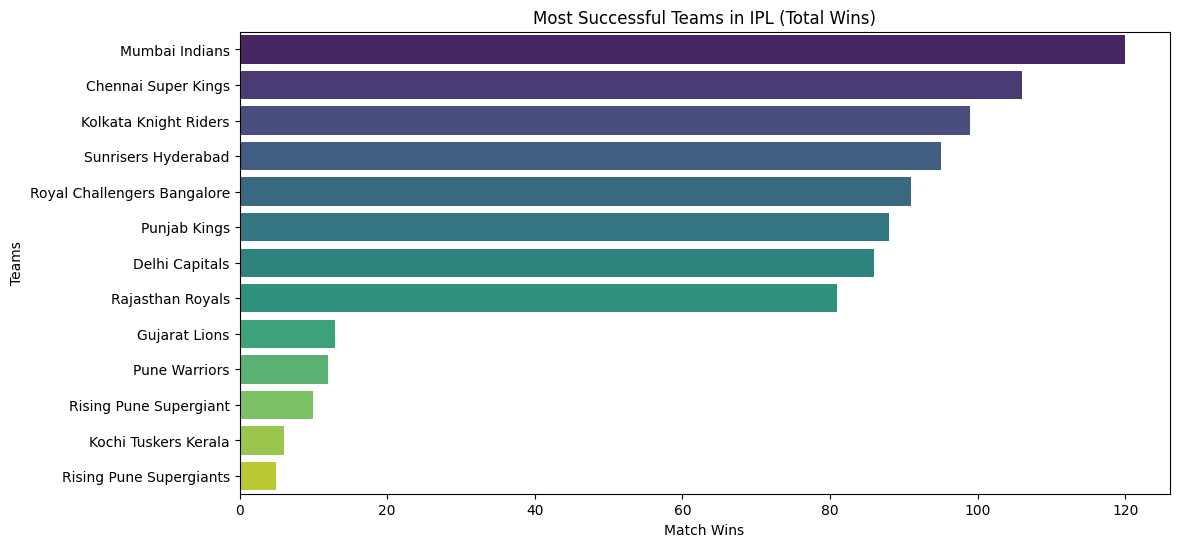

/tmp/ipykernel_2954/1785656927.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='toss_match_winner', data=matches_df, palette='Set2')


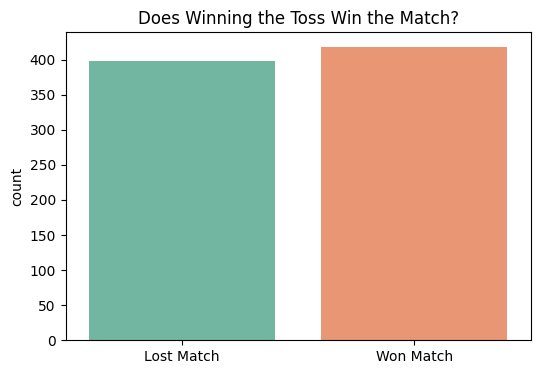

In [9]:
# 1. Total wins per team
plt.figure(figsize=(12, 6))
sns.countplot(y='winner', data=matches_df, order=matches_df['winner'].value_counts().index, palette='viridis')
plt.title('Most Successful Teams in IPL (Total Wins)')
plt.xlabel('Match Wins')
plt.ylabel('Teams')
plt.show()

# 2. Toss Decision Impact: Does winning the toss mean winning the match?
matches_df['toss_match_winner'] = (matches_df['toss_winner'] == matches_df['winner'])

plt.figure(figsize=(6, 4))
sns.countplot(x='toss_match_winner', data=matches_df, palette='Set2')
plt.title('Does Winning the Toss Win the Match?')
plt.xticks([0, 1], ['Lost Match', 'Won Match'])
plt.xlabel('')
plt.show()

Step 7: Perform Deep Dive Ball-by-Ball Analysis (Merging Data). To answer questions about player statistics (like top run-scorers), we need to compute metrics from the ball-by-ball delivery log.

NOTE:

(1) .groupby('batsman') segments our dataset by unique player names.

(2) .sum() then isolates the batsman_runs column and adds up every single run that individual player scored across all 13 years of data.

/tmp/ipykernel_2954/869903960.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='magma')


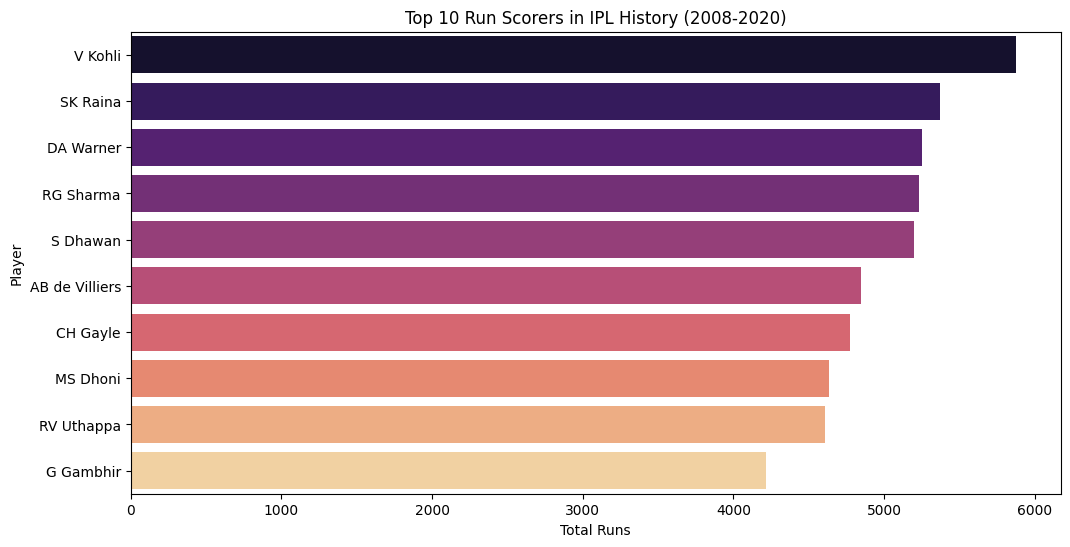

In [10]:
# Aggregate total runs scored by each batsman
top_batsmen = deliveries_df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

# Plot top run scorers
plt.figure(figsize=(12, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='magma')
plt.title('Top 10 Run Scorers in IPL History (2008-2020)')
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.show()

Step 8: Advanced Cross-Dataset Aggregation. Trying to know how the average runs scored per match has changed across different seasons. To achieve this, we must link the season variable from our matches dataframe to our individual delivery entries.

NOTE:

(1) pd.merge(..., on='id', how='left') acts like a SQL JOIN or an advanced Excel VLOOKUP. It references the unique id to safely append contextual match details down to the delivery layer.

(2) sns.lineplot() maps continuous trends over an axis of time, helping you analyze shifts across operational cycles (seasons).

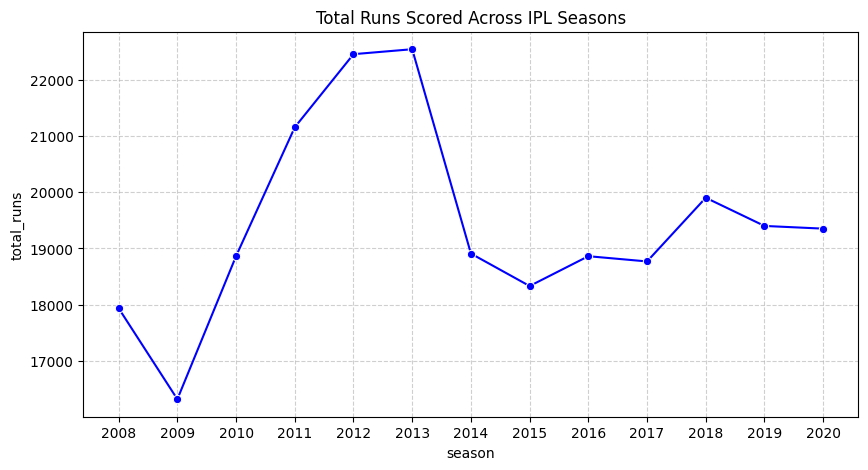

In [11]:
# Merge the 'season' column from matches into the deliveries dataframe using the unique 'id'
merged_df = pd.merge(deliveries_df, matches_df[['id', 'season']], on='id', how='left')

# Calculate total runs per season
runs_per_season = merged_df.groupby('season')['total_runs'].sum().reset_index()

# Plot seasonal progression
plt.figure(figsize=(10, 5))
sns.lineplot(x='season', y='total_runs', data=runs_per_season, marker='o', color='b')
plt.title('Total Runs Scored Across IPL Seasons')
plt.xticks(runs_per_season['season'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()